# Unit 2: 设备连接与数据流控制

## 学习目标

- 理解 RFDuino USB Dongle 的虚拟串口 (VCP) 通信机制
- 掌握 BrainFlow SDK 的安装、初始化和数据采集流程
- 理解 OpenBCI Cyton SDK 字节流命令协议
- 能够解析 33 字节数据包结构
- 实现实时数据流可视化和基本质量控制

---

## 2.1 通信架构概览

```text
┌─────────────┐     RFDuino Gazelle      ┌──────────────┐     USB VCP      ┌──────────┐
│ Cyton Board  │ ◄──────────────────────► │  USB Dongle  │ ◄──────────────► │   PC     │
│  (DEVICE)    │      2.4 GHz ISM          │   (HOST)     │   FTDI FT231X   │ (Python) │
└─────────────┘                           └──────────────┘                  └──────────┘
```

USB Dongle 传给 PC 的数据，在物理层面走的是 USB 协议，但在软件应用层面，它被模拟成了 串口协议。  
简单来说，这是一个“披着 USB 外衣的串口”。

### 通信层次

| 层 | 协议/技术 | 说明 |
|----|-----------|------|
| 物理层 | RFDuino BLE / Gazelle | 2.4 GHz ISM 频段，GFSK 调制 |
| 数据链路层 | Nordic Gazelle | 专有协议栈，吞吐量优于标准 BLE |
| 传输层 | FTDI VCP (USB CDC) | USB → 虚拟串口，921600 bps |
| 应用层 | OpenBCI SDK 命令 | ASCII/字节流命令协议 |

### 虚拟串口 (VCP)

- **Linux**: `/dev/ttyUSB0` (需 `dialout` 组权限)
- **macOS**: `/dev/tty.usbserial-*` (系统自带 FTDI 驱动)
- **Windows**: `COM3` (需安装 [FTDI VCP 驱动](https://ftdichip.com/drivers/vcp-drivers/))

## 2.2 BrainFlow SDK 基础

BrainFlow 是 OpenBCI 官方推荐的多平台数据采集 SDK，支持 Python、C++、Java、C# 等多种语言。

### Board ID 对照表

| Board ID | 设备 | 通道数 | 采样率 (SPS) |
|----------|------|--------|-------------|
| 0 | Cyton (8ch) | 8 | 250 |
| 1 | Ganglion (4ch) | 4 | 200 |
| 2 | Cyton + Daisy (16ch) | 16 | 125 |
| 3 | Synthetic (模拟) | 8 | 256 |

### 数据采集管线

```python
1. BoardShim(board_id, params)   # 创建板卡实例
2. board.prepare_session()       # 初始化会话
3. board.start_stream()          # 开始数据流
4. board.get_board_data()        # 获取数据
5. board.stop_stream()           # 停止数据流
6. board.release_session()       # 释放会话
```

In [ ]:
# ============================================================
# 代码 2.1: 检查环境与设备可用性
# ============================================================
import sys
import brainflow
from brainflow.board_shim import BoardShim, BoardIds
from utils import list_available_boards
from utils import parse_and_print_desc
from utils import create_cyton_board


✅ 成功将 '..' 添加到路径头部。


In [2]:
# 扫描可用设备
print("\n" + "="*60)
print("Scanning for available devices...")
print("="*60)
boards = list_available_boards()
for board in boards:
    print(board)



Scanning for available devices...
{'board_id': 0, 'name': 'Cyton', 'description': {'accel_channels': [9, 10, 11], 'analog_channels': [19, 20, 21], 'ecg_channels': [1, 2, 3, 4, 5, 6, 7, 8], 'eeg_channels': [1, 2, 3, 4, 5, 6, 7, 8], 'eeg_names': 'Fp1,Fp2,C3,C4,P7,P8,O1,O2', 'emg_channels': [1, 2, 3, 4, 5, 6, 7, 8], 'eog_channels': [1, 2, 3, 4, 5, 6, 7, 8], 'marker_channel': 23, 'name': 'Cyton', 'num_rows': 24, 'other_channels': [12, 13, 14, 15, 16, 17, 18], 'package_num_channel': 0, 'sampling_rate': 250, 'timestamp_channel': 22}, 'available_ports': ['COM5']}
{'board_id': 2, 'name': 'CytonDaisy', 'description': {'accel_channels': [17, 18, 19], 'analog_channels': [27, 28, 29], 'ecg_channels': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'eeg_channels': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'eeg_names': 'Fp1,Fp2,C3,C4,P7,P8,O1,O2,F7,F8,F3,F4,T7,T8,P3,P4', 'emg_channels': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16], 'eog_channels': [1, 2, 3, 4, 5, 

d:\AI\qwenpaw\Brain\openbci-4\.venv\lib\site-packages\brainflow\board_shim.py:184: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# OpenBCI 板卡 ID
board_id = BoardIds.CYTON_BOARD.value
# 获取板卡描述
desc_json = parse_and_print_desc(board_id)
# desc = BoardShim.get_board_descr(board_id)

--- 📋 板卡 ID 0 的详细描述 ---
参数名称                 | 值                              | 说明
----------------------------------------------------------------------
accel_channels          | [9, 10, 11]                    | 加速度计通道数
analog_channels         | [19, 20, 21]                   | 模拟通道数
ecg_channels            | [1, 2, 3, 4, 5, 6, 7, 8]       | 心电通道数
eeg_channels            | [1, 2, 3, 4, 5, 6, 7, 8]       | 脑电通道数
eeg_names               | Fp1,Fp2,C3,C4,P7,P8,O1,O2      | 脑电通道名称
emg_channels            | [1, 2, 3, 4, 5, 6, 7, 8]       | 肌电通道数
eog_channels            | [1, 2, 3, 4, 5, 6, 7, 8]       | 眼动通道数
marker_channel          | 23                             | 标记通道数
name                    | Cyton                          | 板卡名称
num_rows                | 24                             | 数据矩阵的总列数
other_channels          | [12, 13, 14, 15, 16, 17, 18]   | 保留通道数
package_num_channel     | 0                              | 包序号通道索引
sampling_rate           | 250                            | 

In [5]:
for board in boards:
    if "error" in board:
        print(f"  {board['error']}")
    else:
        print(f"  {board['name']} (ID={board['board_id']})")
        if board.get("available_ports"):
            for port in board["available_ports"]:
                print(f"    → Serial port: {port}")
        else:
            print(f"    → No serial ports found (Dongle not connected?)")

print("\nTip: If no ports found, plug in the USB Dongle and ensure Cyton is powered on.")
print("The code below will use a SYNTHETIC board to demonstrate the API.")

  Cyton (ID=0)
    → Serial port: COM5
  CytonDaisy (ID=2)
    → Serial port: COM5

Tip: If no ports found, plug in the USB Dongle and ensure Cyton is powered on.
The code below will use a SYNTHETIC board to demonstrate the API.


In [ ]:
# ============================================================
# 代码 2.2: 使用 BrainFlow Synthetic Board 演示数据采集
# ============================================================
import time
import numpy as np
import matplotlib.pyplot as plt

try:
    from brainflow.board_shim import BoardShim, BrainFlowInputParams, BoardIds
    from brainflow.data_filter import DataFilter, FilterTypes, DetrendOperations
    BRAINFLOW_AVAILABLE = True
except ImportError:
    BRAINFLOW_AVAILABLE = False
    print("BrainFlow not available. Using simulated data instead.")

if BRAINFLOW_AVAILABLE:
    # 创建一个空的“配置单”，准备填入串口号、IP地址等连接信息
    params = BrainFlowInputParams()
    # 模拟合成板卡 ID
    board_id = BoardIds.SYNTHETIC_BOARD.value  # -1 or BoardIds.SYNTHETIC_BOARD
    # 实例化一个“设备控制器”
    board = BoardShim(board_id, params)
    print(f"Using board: {BoardShim.get_board_descr(board_id).get('name', 'Synthetic')}")
    
    # 准备会话
    # 是整个流程里最关键的“点火”瞬间
    #  打开物理连接/验证设备身份/初始化硬件寄存器/准备接收缓冲区
    board.prepare_session()
    print("Session prepared.")
    
    # 获取采样率
    sampling_rate = BoardShim.get_sampling_rate(board_id)
    print(f"Sampling rate: {sampling_rate} Hz")
    
    # 获取 EEG 通道索引
    eeg_channels = BoardShim.get_eeg_channels(board_id)
    print(f"EEG channels (BrainFlow indices): {eeg_channels}")
    
    # 开始数据流
    board.start_stream()
    print("Stream started. Collecting 5 seconds of data...")
    
    # 等待数据积累
    time.sleep(5)
    
    # 获取数据
    data = board.get_board_data()  # shape: (n_channels+timestamp, n_samples)
    print(f"Data shape: {data.shape}")
    print(f"Data channels: {data.shape[0]} (includes timestamps, EEG, accelerometer, etc.)")
    
    # 停止流
    board.stop_stream()
    board.release_session()
    print("Session released.")
    
    # 提取 EEG 数据
    eeg_data = data[eeg_channels, :]  # 仅 EEG 通道
    timestamps = data[BoardShim.get_timestamp_channel(board_id), :]
    
    # 显示基本信息
    print(f"\nEEG data shape: {eeg_data.shape}")
    print(f"Collected duration: {(timestamps[-1] - timestamps[0]):.2f} seconds")
    print(f"Channel stats (muV):")
    for i, ch in enumerate(eeg_channels):
        print(f"  Ch{i+1}: mean={eeg_data[i].mean():.1f}, std={eeg_data[i].std():.1f}, "
              f"min={eeg_data[i].min():.1f}, max={eeg_data[i].max():.1f}")

else:
    # Fallback: 使用 helpers.py 中的模拟数据
    from utils import generate_synthetic_eeg
    eeg_data, _ = generate_synthetic_eeg(duration=5.0, sfreq=250.0)
    sampling_rate = 250.0
    print(f"Using simulated EEG data. Shape: {eeg_data.shape}")

Using board: Synthetic
Session prepared.
Sampling rate: 250 Hz
EEG channels (BrainFlow indices): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Stream started. Collecting 5 seconds of data...
Data shape: (32, 1253)
Data channels: 32 (includes timestamps, EEG, accelerometer, etc.)
Session released.

EEG data shape: (16, 1253)
Collected duration: 5.01 seconds
Channel stats (muV):
  Ch1: mean=10.0, std=10.0, min=-4.8, max=24.8
  Ch2: mean=20.0, std=20.1, min=-10.8, max=50.8
  Ch3: mean=30.2, std=30.1, min=-18.6, max=78.5
  Ch4: mean=40.2, std=40.4, min=-27.7, max=107.3
  Ch5: mean=50.1, std=50.7, min=-37.8, max=137.6
  Ch6: mean=59.8, std=61.2, min=-49.8, max=167.5
  Ch7: mean=76.9, std=83.0, min=-88.0, max=370.6
  Ch8: mean=87.2, std=94.4, min=-107.8, max=419.4
  Ch9: mean=101.0, std=111.4, min=-121.8, max=509.0
  Ch10: mean=112.8, std=125.7, min=-112.0, max=567.6
  Ch11: mean=124.9, std=141.4, min=-169.7, max=646.6
  Ch12: mean=137.8, std=156.6, min=-178.3, max=689.6
  Ch13: me

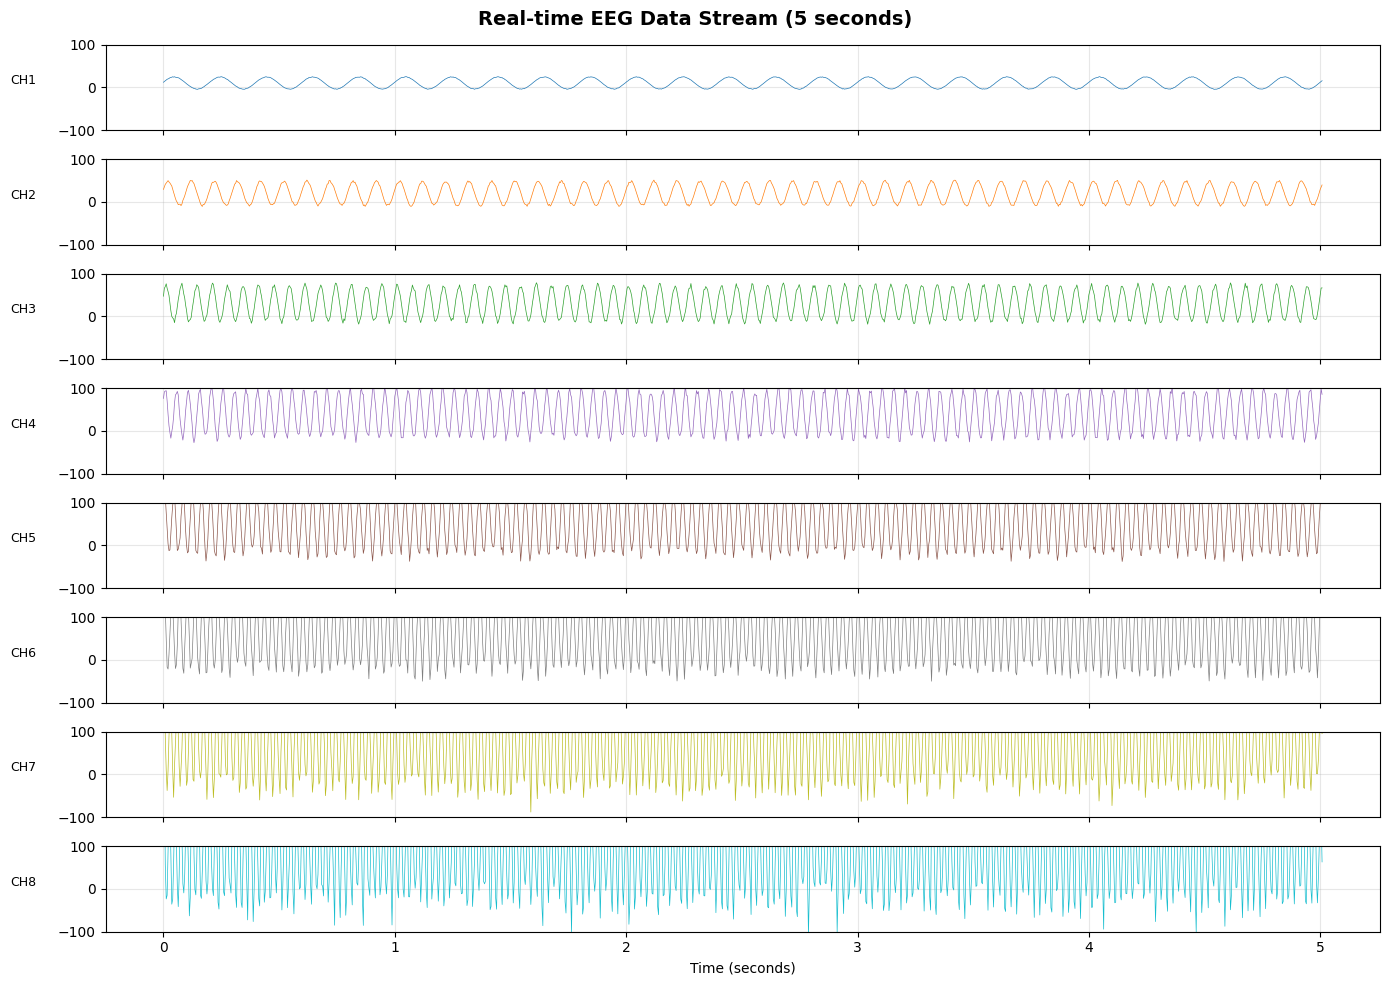


Channel Statistics:
Channel    Mean (muV)   Std (muV)    Min (muV)    Max (muV)   
----------------------------------------------------------
CH1         10.00        10.00        -4.80        24.79       
CH2         19.99        20.06        -10.77       50.77       
CH3         30.20        30.07        -18.60       78.53       
CH4         40.24        40.38        -27.70       107.26      
CH5         50.07        50.68        -37.75       137.60      
CH6         59.78        61.15        -49.85       167.54      
CH7         76.86        83.02        -88.01       370.55      
CH8         87.18        94.41        -107.83      419.41      


In [9]:
# ============================================================
# 代码 2.3: 实时数据可视化
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# 获取 EEG 数据（使用上一节采集或模拟的数据）
n_channels = min(eeg_data.shape[0], 8)
# 生成时间向量：根据采样点数和采样率计算每个采样点对应的时间（秒）
time_vector = np.arange(eeg_data.shape[1]) / sampling_rate

fig, axes = plt.subplots(n_channels, 1, figsize=(14, 10), sharex=True)
if n_channels == 1:
    axes = [axes]
# 用于创建一个等差数列，用于映射到颜色映射表
colors = plt.cm.tab10(np.linspace(0, 1, n_channels))

for i in range(n_channels):
    axes[i].plot(time_vector, eeg_data[i], color=colors[i], linewidth=0.5)
    axes[i].set_ylabel(
        f"CH{i+1}",           # 标签文本：通道编号
        fontsize=9,           # 字体大小
        rotation=0,           # 旋转角度（0度表示水平）
        labelpad=25           # 标签与坐标轴的距离（像素）
    )
    axes[i].set_ylim(-100, 100)
    axes[i].grid(True, alpha=0.3)
    if i < n_channels - 1:
        axes[i].tick_params(labelbottom=False)

axes[-1].set_xlabel("Time (seconds)")
fig.suptitle("Real-time EEG Data Stream (5 seconds)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 统计摘要
print("\nChannel Statistics:")
print(f"{'Channel':<10} {'Mean (muV)':<12} {'Std (muV)':<12} {'Min (muV)':<12} {'Max (muV)':<12}")
print("-" * 58)
for i in range(n_channels):
    print(f"CH{i+1:<9} {eeg_data[i].mean():<12.2f} {eeg_data[i].std():<12.2f} "
          f"{eeg_data[i].min():<12.2f} {eeg_data[i].max():<12.2f}")

## 2.3 OpenBCI Cyton SDK 命令协议

Cyton 通过**字节流命令**进行控制。每个命令以单字符 ASCII 开始，以 `\n` (0x0A) 结束（部分命令例外）。

### 核心命令速查表（v3.0.0+）

| 命令 | 功能 | 参数 | 示例 |
|------|------|------|------|
| `b` | 开始/停止二进制流 | 无 | 发送 `b` 切换 |
| `s` | 停止流 | 无 | `s` |
| `v` | 软件复位 | 无 | `v` |
| `x` | 通道配置 | 8 位 bitmap + 6 位选项 | `x00001111 0X` |
| `d` | 设置所有通道默认 | 无 | `d` |
| `0-6` | 设置通道增益 | 通道号 + 增益码 | `310` → CH3, Gain=24 |
| `z` | 阻抗测试 | 通道号 | `z1` → 测试 CH1 |
| `Z` | 全通道阻抗测试 | 无 | `Z` |
| `[` | 加速度计开 | 无 | `[` |
| `]` | 加速度计关 | 无 | `]` |

### 通道配置命令 `x` 详解

```text
x (CHANNEL_1 ON|OFF) (CH2) ... (CH8) (5-bit option string)

CHANNEL:  1 = ON (default), 0 = OFF
Options (5 chars):
  Position 1: 是否包含加速度计数据 (0=No, 1=Yes)
  Position 2-5: 保留 (设置为 0)

Example: x10000000 10000 → 仅 CH1, 含加速度计
         x11111111 10000 → 全部 8 通道, 含加速度计
```

## 2.4 Cyton 数据包解析器

In [12]:
# ============================================================
# 代码 2.4: Cyton 数据包解析器
# ============================================================
import numpy as np

def parse_cyton_packet(packet: bytes) -> dict:
    """
    解析单个 OpenBCI Cyton 33 字节数据包。
    
    字节布局 (v3.0.0+ 固件):
        Byte 0:       Header (0xA0)
        Byte 1:       Sample Counter (0-255)
        Byte 2-4:     Channel 1 (MSB first, 24-bit signed int)
        Byte 5-7:     Channel 2
        ...
        Byte 23-25:   Channel 8
        Byte 26-27:   Accelerometer X-axis (MSB first, 16-bit signed)
        Byte 28-29:   Accelerometer Y-axis
        Byte 30-31:   Accelerometer Z-axis
        Byte 32:      Footer (0xC0)
        
    注意: OpenBCI 标定因子约 0.02235 μV/count (G=24)
    """
    if len(packet) != 33:
        raise ValueError(f"Expected 33 bytes, got {len(packet)}")
    if packet[0] != 0xA0:
        raise ValueError(f"Invalid header: 0x{packet[0]:02X} (expected 0xA0)")
    if packet[32] != 0xC0:
        raise ValueError(f"Invalid footer: 0x{packet[32]:02X} (expected 0xC0)")
    
    sample_number = packet[1]
    
    # 通道数据 (8 channels × 3 bytes = 24 bytes, starting at offset 2)
    # 比例因子
    SCALE_FACTOR_UV = 0.02235  # μV per count (Gain=24 default)
    channel_data = np.zeros(8, dtype=np.float64)
    
    for ch in range(8):
        offset = 2 + ch * 3
        # ADS1299 使用“大端序”（MSB first）
        # byte1  byte2  byte3
        # MSB           LSB
        # ADS1299 输出的 24位二进制补码
        raw = (int(packet[offset]) << 16) | \
              (int(packet[offset + 1]) << 8) | \
              int(packet[offset + 2])
        # 符号扩展 (核心难点) 
        # 通信协议中出现补码，需要逻辑层来判断处理
        # 正常都是由底层代码处理
        if raw & 0x800000:   # 逻辑层来判断
            raw -= 0x1000000 # mod运算
        channel_data[ch] = raw * SCALE_FACTOR_UV
    
    # 加速度计数据 (3 axes × 2 bytes = 6 bytes, starting at offset 26)
    accel_data = np.zeros(3, dtype=np.int16)
    for axis in range(3):
        offset = 26 + axis * 2
        # 大端序 16-bit 有符号整数
        val = (int(packet[offset]) << 8) | int(packet[offset + 1])
        if val & 0x8000:
            val -= 0x10000
        accel_data[axis] = val
    
    return {
        "sample_number": sample_number,
        "channel_data": channel_data,    # μV
        "accel_data": accel_data,        # raw LIS3DH counts
    }

# ---- 测试数据包解析器 ----
print("测试 Cyton 数据包解析器...\n")

# 构造 一个合法的测试数据包
test_packet = bytearray(33)
test_packet[0] = 0xA0       # Header
test_packet[1] = 42         # Sample counter
# 设置 CH1 为 100000 counts (约 2235 μV)
ch1_raw = 100000
test_packet[2] = (ch1_raw >> 16) & 0xFF
test_packet[3] = (ch1_raw >> 8) & 0xFF
test_packet[4] = ch1_raw & 0xFF
# 设置加速度计 X = -500
accel_x = -500 & 0xFFFF # 将有符号整数 -500 转换为 16 位无符号整数的补码表示
test_packet[26] = (accel_x >> 8) & 0xFF
test_packet[27] = accel_x & 0xFF
test_packet[32] = 0xC0      # Footer

# 解析
result = parse_cyton_packet(bytes(test_packet))
print(f"Sample Number:  {result['sample_number']}")
print(f"CH1 (raw=100000): {result['channel_data'][0]:.2f} μV")
print(f"  Expected:       {100000 * 0.02235:.2f} μV")
print(f"Accel X:          {result['accel_data'][0]} (raw)")

# 测试边界情况：负值（二进制补码）
ch_neg = -50000 & 0xFFFFFF  # 24-bit 补码
test_packet[2] = (ch_neg >> 16) & 0xFF
test_packet[3] = (ch_neg >> 8) & 0xFF
test_packet[4] = ch_neg & 0xFF
result2 = parse_cyton_packet(bytes(test_packet))
print(f"\nCH1 (raw=-50000): {result2['channel_data'][0]:.2f} μV")
print(f"  Expected:        {-50000 * 0.02235:.2f} μV")

测试 Cyton 数据包解析器...

Sample Number:  42
CH1 (raw=100000): 2235.00 μV
  Expected:       2235.00 μV
Accel X:          -500 (raw)

CH1 (raw=-50000): -1117.50 μV
  Expected:        -1117.50 μV


In [2]:
# ============================================================
# 代码 2.5: 串口扫描工具（无需 BrainFlow）
# ============================================================
"""
如果 BrainFlow 无法使用，可以通过 pyserial 直接扫描串口。
此代码段展示如何独立于 BrainFlow 检测 Cyton 设备。
"""
import sys
import glob

def scan_serial_ports():
    """跨平台串口扫描"""
    ports = []
    
    # Python 3.3+ 使用 serial.tools.list_ports
    try:
        import serial.tools.list_ports
        for port in serial.tools.list_ports.comports():
            ports.append({
                "device": port.device,
                "description": port.description,
                "hwid": port.hwid,
                "manufacturer": getattr(port, 'manufacturer', 'Unknown')
            })
        return ports
    except ImportError:
        pass
    
    # 备用方案: 直接扫描 /dev
    if sys.platform.startswith("linux"):
        return [{"device": d, "description": "", "hwid": ""} 
                for d in glob.glob("/dev/ttyUSB*") + glob.glob("/dev/ttyACM*")]
    elif sys.platform == "darwin":
        return [{"device": d, "description": "", "hwid": ""}
                for d in glob.glob("/dev/tty.usbserial-*") + glob.glob("/dev/tty.usbmodem*")]
    else:
        return []

# 扫描
print("Scanning serial ports...\n")
ports = scan_serial_ports()
if ports:
    print(f"Found {len(ports)} serial port(s):")
    for p in ports:
        print(f"  {p['device']:<25} {p.get('description', '')}")
        if p.get('manufacturer'):
            print(f"    Manufacturer: {p['manufacturer']}")
        # FTDI 芯片的典型 HWID
        if 'FTDI' in p.get('hwid', '') or '0403' in p.get('hwid', ''):
            print(f"    >>> This looks like an OpenBCI Dongle (FTDI chip)!")
else:
    print("No serial ports found.")
    print("Make sure the USB Dongle is connected and Cyton is powered on.")

print("\nNote: On Linux, you may need to add yourself to the 'dialout' group:")
print("  sudo usermod -a -G dialout $USER")
print("  (Log out and back in for changes to take effect)")

Scanning serial ports...

No serial ports found.
Make sure the USB Dongle is connected and Cyton is powered on.

Note: On Linux, you may need to add yourself to the 'dialout' group:
  sudo usermod -a -G dialout $USER
  (Log out and back in for changes to take effect)


## 2.4 BrainFlow 数据缓冲区管理

BrainFlow 内部维护一个环形缓冲区。关键 API：

- `get_board_data(num_samples)`: 获取最新 N 个样本
- `get_current_board_data(num_samples)`: 获取最近 N 个样本（不清除缓冲区）
- `get_board_data_count()`: 查询缓冲区中可用样本数
- `insert_marker(value)`: 插入事件标记

### 数据数组索引

Cyton board 的数据数组包含以下通道（按行索引）：

| 索引范围 | 内容 |
|----------|------|
| `[1..8]` | EEG 通道 1-8 (μV) |
| `[9..11]` | 加速度计 X, Y, Z (raw) |
| `[12]` | 包计数器 |
| `[13]` | 时间戳 (Unix ms) |

In [ ]:
# ============================================================
# 代码 2.6: 连续数据采集与滚动可视化 (模拟)
# ============================================================
"""
演示连续数据采集的概念。使用模拟数据模拟实时流。
真实场景中，将 while True 循环中的数据源替换为 board.get_board_data()。
"""
import time
import numpy as np
from IPython.display import clear_output


def simulate_stream_buffer(duration=5.0, sfreq=250.0, n_channels=4):
    """
    模拟连续数据流，逐步展示累积的数据。
    真实场景：board.start_stream() + 周期性 board.get_board_data()
    """
    from utils import generate_synthetic_eeg
    
    data, _ = generate_synthetic_eeg(duration=duration, sfreq=sfreq,
                                      n_channels=n_channels, seed=42)
    
    # 模拟分块到达（每 0.5 秒一块）
    chunk_duration = 0.5  # seconds
    chunk_samples = int(chunk_duration * sfreq)
    
    # 积累数据
    accumulated = np.zeros((n_channels, 0))
    
    # data.shape[1] 是时间维度上的样本点数（总采样点数）
    # data 的形状为 (n_channels, n_samples)，所以 data.shape[1] 表示所有通道的总采样点数
    for start in range(0, data.shape[1], chunk_samples):
        end = min(start + chunk_samples, data.shape[1])
        chunk = data[:, start:end]
        # 将新采集的数据块 chunk 水平拼接到已积累的数据 accumulated 后面
        # np.hstack 表示水平方向（列方向）堆叠数组，实现数据的累积
        accumulated = np.hstack([accumulated, chunk])
        
        # 是 IPython/Jupyter Notebook 环境中用于动态刷新界面的核心指令
        clear_output(wait=True)
        # 计算当前已经累积的音频/信号数据的总时长
        current_duration = accumulated.shape[1] / sfreq
        print(f"Streaming... {current_duration:.1f}s / {duration:.1f}s "
              f"({accumulated.shape[1]} samples)")
        
        # 简单统计
        for ch in range(min(n_channels, 4)):
            # 对时间维度（即该通道累积的所有数据点）求平均值和标准差
            # 这行代码计算的是该通道在当前整个记录时长内的直流分量（DC Component）或基线电平
            print(f"  CH{ch+1}: μ={accumulated[ch].mean():.2f}, "
                  f"σ={accumulated[ch].std():.2f}")
        
        time.sleep(0.3)  # 模拟采集延时
    
    print(f"\nStream complete! Total samples: {accumulated.shape[1]}")
    return accumulated

# 运行模拟
accumulated_data = simulate_stream_buffer(duration=3.0, sfreq=250.0, n_channels=4)

print("\nData shape:", accumulated_data.shape)
print("Buffer statistics:")
print(f"  Duration:      {accumulated_data.shape[1]/250:.2f} s")
print(f"  Total samples: {accumulated_data.shape[1]}")
print(f"  Memory:         {accumulated_data.nbytes / 1024:.1f} KB")

Streaming... 3.0s / 3.0s (750 samples)
  CH1: μ=0.08, σ=12.05
  CH2: μ=0.13, σ=13.72
  CH3: μ=0.23, σ=16.97
  CH4: μ=0.01, σ=19.44

Stream complete! Total samples: 750

Data shape: (4, 750)
Buffer statistics:
  Duration:      3.00 s
  Total samples: 750
  Memory:         23.4 KB


## 单元小结

本单元涵盖：
1. RFDuino USB Dongle 的 VCP 通信机制和跨平台驱动安装
2. BrainFlow SDK 的完整数据采集管线（prepare → start → get → stop → release）
3. OpenBCI Cyton SDK 字节流命令协议 (通道配置、增益、阻抗等)
4. 33 字节数据包的详细解析（24-bit ADC × 8ch + 加速度计）
5. 串口扫描和实时数据可视化

**下一步：** Unit 3 将学习如何对采集到的原始信号进行滤波和预处理。